In [2]:
import pandas as pd

In [3]:
import os

In [4]:
print(os.getcwd())

c:\Users\Prime\OneDrive\Desktop\Bilingual-Spam-Detector\notebooks


In [6]:
df = pd.read_csv("../data/raw/spam.csv", encoding="latin-1")

In [7]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df.shape

(5572, 5)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [11]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [12]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [14]:
df = df[['v1','v2']]

## Message Length Analysis

### Observation

- A new feature named `length` was created to store the number of characters in each SMS message.
- The average length of spam messages is generally higher than ham messages.
- This indicates that spam messages often contain promotional text, offers, links, or detailed content.
- Message length can be used as an additional feature during analysis.


In [15]:
df.columns

Index(['v1', 'v2'], dtype='str')

In [17]:
df.columns = ['label','message']

In [18]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [20]:
df['label'].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

Matplotlib is building the font cache; this may take a moment.


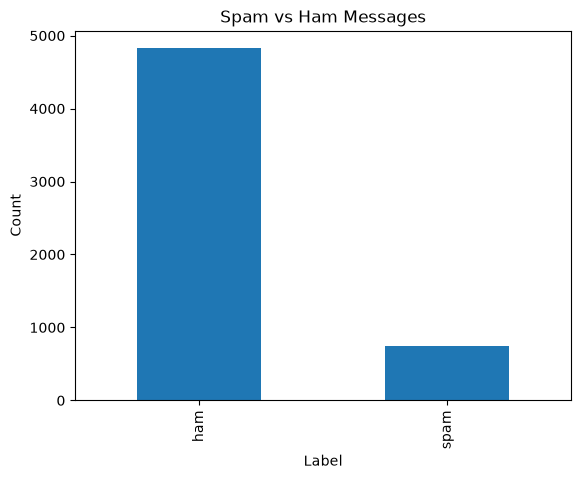

In [21]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Messages")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [22]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [23]:
df['label'].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

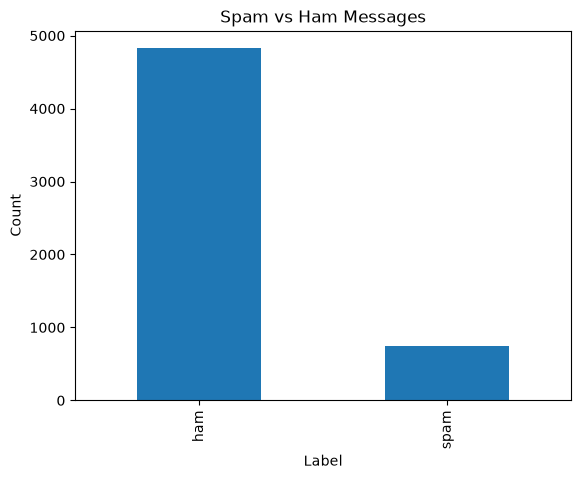

In [24]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Messages")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [25]:
df["length"] = df["message"].apply(len)

In [26]:
df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [27]:
df.groupby("label")["length"].mean()

label
ham      71.023627
spam    138.866131
Name: length, dtype: float64

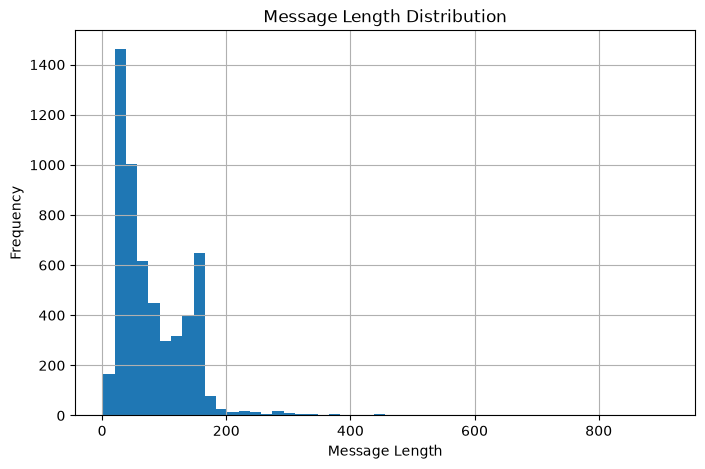

In [28]:
plt.figure(figsize=(8,5))
df["length"].hist(bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()